# 03 – Forecasting Models: Day-Ahead Forecasts

Dieses Notebook erzeugt die Forecasts für die spätere Bidding-Evaluation.

## Ziel

Wir trainieren verschiedene Forecasting-Modelle im **Day-Ahead-Setup**.  
Für die Prognose der Produktion zum Zeitpunkt \(t\) werden nur Informationen verwendet, die mindestens 24 Stunden vorher bekannt wären.

## Wichtig

Dieses Notebook bewertet die Modelle **nicht final über RMSE**.  
RMSE, MAE und Pinball Loss dienen nur zur deskriptiven Einordnung.

Der zentrale Vergleich erfolgt später in Notebook 04 über:

```text
Forecast → Bid → Profit / Newsvendor Loss
```

## Modellgruppen

### Point Forecasts
- Persistence 24h
- Elastic Net
- Random Forest
- Gradient Boosting

### Probabilistic Forecasts
- Quantile Regression
- Quantile Regression Forest (QRF)
- Quantile Gradient Boosting
- Quantile Neural Network


## 1. Setup und Imports

In [27]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"

RESULTS_DIR = PROJECT_ROOT / "results"
FORECAST_DIR = RESULTS_DIR / "forecasts"
MODELS_DIR = RESULTS_DIR / "models"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

for directory in [FORECAST_DIR, MODELS_DIR, TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)


Project root: C:\Users\felix\Documents\AI1\wind_bidding_project
Data path: C:\Users\felix\Documents\AI1\wind_bidding_project\data\processed\final_dataset.csv


## 2. Modell-Imports aus `src.models`

In [28]:
from src.models import (
    elastic_net,
    random_forest,
    gradient_boosting,
    quantile_regression,
    quantile_regression_forest,
    quantile_gradient_boosting,
    quantile_neural_network,
)


## 3. Daten laden

Erwartete Eingabedatei:

```text
data/processed/final_dataset.csv
```

Mindestens benötigte Spalten:

```text
timestamp
power
```

Optional:

```text
wind_speed
```


In [29]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print("Shape:", df.shape)
df.head()


Shape: (72360, 10)


,timestamp,power,wind_speed,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos
0,2017-03-23 10:00:00,19.591667,1.299722,10,3,3,0.500000,-0.866025,0.433884,-0.900969
1,2017-03-23 11:00:00,63.941667,1.653889,11,3,3,0.258819,-0.965926,0.433884,-0.900969
2,2017-03-23 14:00:00,57.825000,1.389583,14,3,3,-0.500000,-0.866025,0.433884,-0.900969
3,2017-03-23 15:00:00,184.566667,2.021111,15,3,3,-0.707107,-0.707107,0.433884,-0.900969
4,2017-04-03 08:00:00,974.175000,3.721111,8,0,4,0.866025,-0.500000,0.000000,1.000000


## 4. Day-Ahead Feature Engineering (Gate-Close-Referenzierung)

Alle Gebote für Tag D+1 werden um **12:00 Uhr Mittag** von Tag D abgegeben (EPEX Gate Close).
Deshalb wird jedes Feature relativ zum **Gate-Close-Zeitpunkt** berechnet:

$$\text{gate\_close}(t) = \text{midnight}(t) - 12\,\text{h} = \text{noon of day } D$$

Alle 24 Zielstunden teilen denselben Gate-Close und damit exakt dieselbe Informationsbasis.
Das vermeidet sowohl Data Leakage als auch die Inkonsistenz eines fixen relativen Lags
(lag\_36 war für Zielstunde 0 = 12 h Abstand, für Stunde 23 = 59 h Abstand).

In [30]:
df_model = df.copy()

df_model["energy_mwh"] = df_model["power"].clip(lower=0) / 1000

df_model["hour"]      = df_model["timestamp"].dt.hour
df_model["dayofweek"] = df_model["timestamp"].dt.dayofweek
df_model["month"]     = df_model["timestamp"].dt.month

df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)
df_model["dow_sin"]  = np.sin(2 * np.pi * df_model["dayofweek"] / 7)
df_model["dow_cos"]  = np.cos(2 * np.pi * df_model["dayofweek"] / 7)

# Gate-close: alle 24 Stunden-Gebote von Tag D+1 werden um 12:00 Uhr Tag D abgegeben.
# gate_close = Mitternacht des Zieldatums − 12 h = Mittag des Vortags.
df_model["gate_close"] = (
    df_model["timestamp"].dt.normalize() - pd.Timedelta(hours=12)
)

# Vollständiges Stundengitter für korrekte Rolling-Windows über eventuelle Datenlücken.
full_hourly_idx = pd.date_range(
    df["timestamp"].min().normalize() - pd.Timedelta(days=8),
    df["timestamp"].max(),
    freq="h",
)

energy_hourly = (
    df_model.set_index("timestamp")["energy_mwh"]
    .groupby(level=0).mean()       # Sicherheit: Duplikate kollabieren
    .reindex(full_hourly_idx)      # NaN für fehlende Stunden
)
energy_roll24  = energy_hourly.rolling(24,  min_periods=12).mean()
energy_std24   = energy_hourly.rolling(24,  min_periods=12).std()
energy_roll168 = energy_hourly.rolling(168, min_periods=72).mean()
energy_std168  = energy_hourly.rolling(168, min_periods=72).std()

# Punkt-Features: Produktionswert zu Gate-Close und n Stunden davor
for offset_h in [0, 12, 24, 48, 168]:
    col = "energy_at_gate" if offset_h == 0 else f"energy_gate_m{offset_h}h"
    df_model[col] = (
        df_model["gate_close"] - pd.Timedelta(hours=offset_h)
    ).map(energy_hourly).values

# Rolling-Features zum Gate-Close-Zeitpunkt
df_model["energy_roll24_at_gate"]      = df_model["gate_close"].map(energy_roll24).values
df_model["energy_roll_std24_at_gate"]  = df_model["gate_close"].map(energy_std24).values
df_model["energy_roll168_at_gate"]     = df_model["gate_close"].map(energy_roll168).values
df_model["energy_roll_std168_at_gate"] = df_model["gate_close"].map(energy_std168).values

if "wind_speed" in df_model.columns:
    wind_hourly = (
        df_model.set_index("timestamp")["wind_speed"]
        .groupby(level=0).mean()
        .reindex(full_hourly_idx)
    )
    wind_roll24  = wind_hourly.rolling(24,  min_periods=12).mean()
    wind_std24   = wind_hourly.rolling(24,  min_periods=12).std()
    wind_roll168 = wind_hourly.rolling(168, min_periods=72).mean()
    wind_std168  = wind_hourly.rolling(168, min_periods=72).std()

    for offset_h in [0, 12, 24, 168]:
        col = "wind_at_gate" if offset_h == 0 else f"wind_gate_m{offset_h}h"
        df_model[col] = (
            df_model["gate_close"] - pd.Timedelta(hours=offset_h)
        ).map(wind_hourly).values

    df_model["wind_roll24_at_gate"]      = df_model["gate_close"].map(wind_roll24).values
    df_model["wind_roll_std24_at_gate"]  = df_model["gate_close"].map(wind_std24).values
    df_model["wind_roll168_at_gate"]     = df_model["gate_close"].map(wind_roll168).values
    df_model["wind_roll_std168_at_gate"] = df_model["gate_close"].map(wind_std168).values
else:
    warnings.warn("'wind_speed' nicht gefunden – Wind-Features werden übersprungen.")

df_model.head()

,timestamp,power,wind_speed,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos,...,energy_roll168_at_gate,energy_roll_std168_at_gate,wind_at_gate,wind_gate_m12h,wind_gate_m24h,wind_gate_m168h,wind_roll24_at_gate,wind_roll_std24_at_gate,wind_roll168_at_gate,wind_roll_std168_at_gate
0,2017-03-23 10:00:00,19.591667,1.299722,10,3,3,0.500000,-0.866025,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-03-23 11:00:00,63.941667,1.653889,11,3,3,0.258819,-0.965926,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017-03-23 14:00:00,57.825000,1.389583,14,3,3,-0.500000,-0.866025,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017-03-23 15:00:00,184.566667,2.021111,15,3,3,-0.707107,-0.707107,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017-04-03 08:00:00,974.175000,3.721111,8,0,4,0.866025,-0.500000,0.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Feature-Set und Zielvariable

In [31]:
BASE_FEATURES = [
    "energy_at_gate",            # Produktion bei Gate-Close (12:00, Tag D)
    "energy_gate_m12h",          # Produktion 12h vor Gate-Close (00:00, Tag D)
    "energy_gate_m24h",          # Produktion 24h vor Gate-Close (12:00, Tag D-1)
    "energy_gate_m48h",          # Produktion 48h vor Gate-Close
    "energy_gate_m168h",         # Produktion 168h vor Gate-Close (gleiche Wochenstunde)
    "energy_roll24_at_gate",     # 24h-Mittelwert bis Gate-Close
    "energy_roll_std24_at_gate", # 24h-Standardabweichung bis Gate-Close
    "energy_roll168_at_gate",    # 168h-Mittelwert (Wochenmuster)
    "energy_roll_std168_at_gate",
    "hour_sin", "hour_cos",      # Zielstunde (zyklisch kodiert)
    "dow_sin",  "dow_cos",       # Ziel-Wochentag (zyklisch)
    "month",                     # Saisonalität
]

WIND_LAG_FEATURES = [f for f in [
    "wind_at_gate",
    "wind_gate_m12h",
    "wind_gate_m24h",
    "wind_gate_m168h",
    "wind_roll24_at_gate",
    "wind_roll_std24_at_gate",
    "wind_roll168_at_gate",
    "wind_roll_std168_at_gate",
] if f in df_model.columns]

FEATURES_DAY_AHEAD = BASE_FEATURES + WIND_LAG_FEATURES

TARGET = "energy_mwh"

df_model = df_model.dropna(subset=FEATURES_DAY_AHEAD + [TARGET]).reset_index(drop=True)

X = df_model[FEATURES_DAY_AHEAD]
y = df_model[TARGET]

print("Number of observations:", len(df_model))
print("Number of features:", len(FEATURES_DAY_AHEAD))
print("Features:")
for f in FEATURES_DAY_AHEAD:
    print(f"  - {f}")
X.head()

Number of observations: 69076
Number of features: 22
Features:
  - energy_at_gate
  - energy_gate_m12h
  - energy_gate_m24h
  - energy_gate_m48h
  - energy_gate_m168h
  - energy_roll24_at_gate
  - energy_roll_std24_at_gate
  - energy_roll168_at_gate
  - energy_roll_std168_at_gate
  - hour_sin
  - hour_cos
  - dow_sin
  - dow_cos
  - month
  - wind_at_gate
  - wind_gate_m12h
  - wind_gate_m24h
  - wind_gate_m168h
  - wind_roll24_at_gate
  - wind_roll_std24_at_gate
  - wind_roll168_at_gate
  - wind_roll_std168_at_gate


,energy_at_gate,energy_gate_m12h,energy_gate_m24h,energy_gate_m48h,energy_gate_m168h,energy_roll24_at_gate,energy_roll_std24_at_gate,energy_roll168_at_gate,energy_roll_std168_at_gate,hour_sin,...,dow_cos,month,wind_at_gate,wind_gate_m12h,wind_gate_m24h,wind_gate_m168h,wind_roll24_at_gate,wind_roll_std24_at_gate,wind_roll168_at_gate,wind_roll_std168_at_gate
0,0.549411,0.875589,0.784072,0.006883,1.379894,0.855276,0.291062,0.748767,0.520598,0.000000,...,-0.900969,4,5.653704,5.694444,5.079259,4.26537,5.696127,0.428065,5.077289,1.158432
1,0.549411,0.875589,0.784072,0.006883,1.379894,0.855276,0.291062,0.748767,0.520598,0.258819,...,-0.900969,4,5.653704,5.694444,5.079259,4.26537,5.696127,0.428065,5.077289,1.158432
2,0.549411,0.875589,0.784072,0.006883,1.379894,0.855276,0.291062,0.748767,0.520598,0.500000,...,-0.900969,4,5.653704,5.694444,5.079259,4.26537,5.696127,0.428065,5.077289,1.158432
3,0.549411,0.875589,0.784072,0.006883,1.379894,0.855276,0.291062,0.748767,0.520598,0.707107,...,-0.900969,4,5.653704,5.694444,5.079259,4.26537,5.696127,0.428065,5.077289,1.158432
4,0.549411,0.875589,0.784072,0.006883,1.379894,0.855276,0.291062,0.748767,0.520598,0.866025,...,-0.900969,4,5.653704,5.694444,5.079259,4.26537,5.696127,0.428065,5.077289,1.158432


## 6. Zeitlicher Train-Test-Split

In [32]:
TEST_SIZE = 0.2

split_idx = int(len(df_model) * (1 - TEST_SIZE))

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

test_timestamps = df_model.loc[X_test.index, "timestamp"].reset_index(drop=True)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Test period:", test_timestamps.min(), "bis", test_timestamps.max())


Train: (55260, 22) (55260,)
Test: (13816, 22) (13816,)
Test period: 2023-12-07 03:00:00 bis 2025-08-31 23:00:00


## 7. Hilfsfunktionen für deskriptive Forecast-Metriken

In [33]:

def evaluate_point_forecast(y_true, y_pred) -> dict[str, float]:
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }


def add_point_metrics(rows: list[dict], model_name: str, y_true, y_pred) -> None:
    row = {"model": model_name}
    row.update(evaluate_point_forecast(y_true, y_pred))
    rows.append(row)


def clip_non_negative(values):
    """
    Ensure non-negative wind energy forecasts.
    Wind production cannot be negative.
    """
    return np.clip(np.asarray(values, dtype=float), 0, None)


def enforce_quantile_monotonicity(preds: pd.DataFrame) -> pd.DataFrame:
    """
    Enforce q10 <= q25 <= q50 <= q75 <= q90 row-wise.

    This is a pragmatic post-processing step to avoid quantile crossing
    when quantile models are trained independently.
    """
    quantile_cols = [col for col in preds.columns if col.startswith("q")]

    if not quantile_cols:
        return preds.copy()

    fixed = preds.copy()
    fixed[quantile_cols] = np.sort(fixed[quantile_cols].to_numpy(), axis=1)
    return fixed


def check_quantile_monotonicity(preds: pd.DataFrame, model_name: str) -> None:
    """
    Print whether quantile predictions are monotonic.
    """
    quantile_cols = [col for col in preds.columns if col.startswith("q")]

    if not quantile_cols:
        print(f"{model_name}: no quantile columns found.")
        return

    values = preds[quantile_cols].to_numpy()
    violations = np.sum(np.any(np.diff(values, axis=1) < 0, axis=1))

    if violations == 0:
        print(f"{model_name}: quantiles are monotonic.")
    else:
        print(f"{model_name}: fixed {violations} rows with quantile crossing.")


# Teil A – Point Forecast Models

Point Forecasts liefern genau einen Vorhersagewert pro Zeitpunkt.  
Sie werden später im Bidding als direktes Gebot interpretiert:

\[
b_t = \hat{y}_t
\]

Im finalen Vergleich werden sie nicht über RMSE gegen probabilistische Modelle ausgespielt, sondern über ihre wirtschaftliche Bidding-Performance.


## 8. Point Forecasts trainieren

In [34]:
point_metrics_rows = []

# Persistence (Gate): Vorhersage = Produktion zum Gate-Close-Zeitpunkt für alle 24h des Folgetags.
y_pred_persistence_gate = df_model.loc[X_test.index, "energy_at_gate"].to_numpy()
y_pred_persistence_gate = clip_non_negative(y_pred_persistence_gate)

en_model = elastic_net.train(
    X_train,
    y_train,
    alpha=0.1,
    l1_ratio=0.5,
    random_state=42,
)
y_pred_elastic_net = elastic_net.predict(en_model, X_test)
y_pred_elastic_net = clip_non_negative(y_pred_elastic_net)

rf_model = random_forest.train(
    X_train,
    y_train,
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
)
y_pred_random_forest = random_forest.predict(rf_model, X_test)
y_pred_random_forest = clip_non_negative(y_pred_random_forest)

gb_model = gradient_boosting.train(
    X_train, y_train,
    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=20,
)
y_pred_gradient_boosting = gradient_boosting.predict(gb_model, X_test)
y_pred_gradient_boosting = clip_non_negative(y_pred_gradient_boosting)

point_predictions = {
    "Persistence_gate":  y_pred_persistence_gate,
    "Elastic_Net":       y_pred_elastic_net,
    "Random_Forest":     y_pred_random_forest,
    "Gradient_Boosting": y_pred_gradient_boosting,
}

for model_name, y_pred in point_predictions.items():
    add_point_metrics(point_metrics_rows, model_name, y_test, y_pred)

point_metrics = pd.DataFrame(point_metrics_rows).sort_values("RMSE")
point_metrics

,model,MAE,RMSE,R2
3,Gradient_Boosting,1.272480,1.682719,0.212914
1,Elastic_Net,1.263475,1.696554,0.199918
2,Random_Forest,1.280768,1.702543,0.194259
0,Persistence_gate,1.332470,2.042285,-0.159396


## 9. Deskriptive Grafik: Point Forecast RMSE

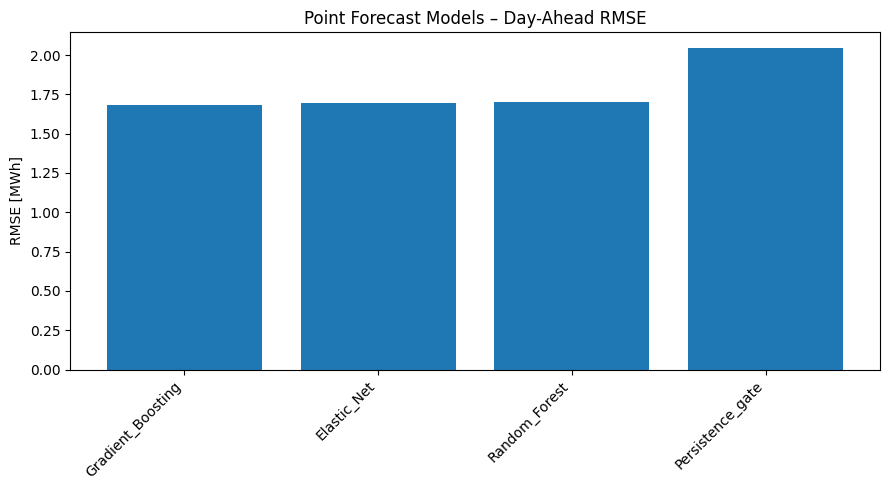

In [35]:
plot_df = point_metrics.sort_values("RMSE")

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE [MWh]")
plt.title("Point Forecast Models – Day-Ahead RMSE")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "point_forecast_rmse_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


# Teil B – Probabilistic Forecast Models

Probabilistische Modelle liefern mehrere Quantile pro Zeitpunkt.

Für das Newsvendor-Bidding ist das besonders relevant, weil je nach Kostenstruktur unterschiedliche Quantile als Gebot verwendet werden können.


## 10. Probabilistische Modelle trainieren

In [36]:

QUANTILES = (0.1, 0.25, 0.5, 0.75, 0.9)

prob_median_metrics_rows = []
pinball_rows = []

# Quantile Regression
qr_models = quantile_regression.train(
    X_train,
    y_train,
    quantiles=QUANTILES,
)
qr_preds = quantile_regression.predict_all(qr_models, X_test)
qr_preds = enforce_quantile_monotonicity(qr_preds).clip(lower=0)
check_quantile_monotonicity(qr_preds, "Quantile Regression")

y_pred_qr_q50 = qr_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "Quantile_Regression_q50", y_test, y_pred_qr_q50)

qr_pinball = quantile_regression.evaluate_quantiles(y_test, qr_preds)
qr_pinball["model"] = "Quantile_Regression"
pinball_rows.append(qr_pinball)

# Quantile Regression Forest
qrf_model = quantile_regression_forest.train(
    X_train,
    y_train,
    n_estimators=300,
    min_samples_leaf=5,
    random_state=42,
)
qrf_preds = quantile_regression_forest.predict_all(
    qrf_model,
    X_test,
    quantiles=QUANTILES,
)
qrf_preds = enforce_quantile_monotonicity(qrf_preds).clip(lower=0)
check_quantile_monotonicity(qrf_preds, "QRF")

y_pred_qrf_q50 = qrf_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "QRF_q50", y_test, y_pred_qrf_q50)

qrf_pinball = quantile_regression_forest.evaluate_quantiles(y_test, qrf_preds)
qrf_pinball["model"] = "QRF"
pinball_rows.append(qrf_pinball)

# Quantile Gradient Boosting
qgb_models = quantile_gradient_boosting.train(
    X_train, y_train,
    quantiles=QUANTILES,
    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=20,
)
qgb_preds = quantile_gradient_boosting.predict_all(qgb_models, X_test)
qgb_preds = enforce_quantile_monotonicity(qgb_preds).clip(lower=0)
check_quantile_monotonicity(qgb_preds, "Quantile Gradient Boosting")

y_pred_qgb_q50 = qgb_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "Quantile_Gradient_Boosting_q50", y_test, y_pred_qgb_q50)

qgb_pinball = quantile_gradient_boosting.evaluate_quantiles(y_test, qgb_preds)
qgb_pinball["model"] = "Quantile_Gradient_Boosting"
pinball_rows.append(qgb_pinball)

# Quantile Neural Network
qnn_model = quantile_neural_network.train(
    X_train,
    y_train,
    quantiles=QUANTILES,
    hidden_layer_sizes=(64, 32),
    dropout=0.1,
    learning_rate=0.001,
    weight_decay=0.0001,
    batch_size=64,
    max_epochs=500,
    patience=30,
    random_state=42,
)
qnn_preds = quantile_neural_network.predict_all(qnn_model, X_test)
qnn_preds = enforce_quantile_monotonicity(qnn_preds).clip(lower=0)
check_quantile_monotonicity(qnn_preds, "Quantile Neural Network")

y_pred_qnn_q50 = qnn_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "Quantile_Neural_Network_q50", y_test, y_pred_qnn_q50)

qnn_pinball = quantile_neural_network.evaluate_quantiles(y_test, qnn_preds)
qnn_pinball["model"] = "Quantile_Neural_Network"
pinball_rows.append(qnn_pinball)

prob_median_metrics = pd.DataFrame(prob_median_metrics_rows).sort_values("RMSE")
pinball_metrics = pd.concat(pinball_rows, ignore_index=True)
pinball_metrics = pinball_metrics[["model", "quantile", "pinball_loss"]]

prob_median_metrics


Quantile Regression: quantiles are monotonic.
QRF: quantiles are monotonic.
Quantile Gradient Boosting: quantiles are monotonic.
Quantile Neural Network: quantiles are monotonic.


,model,MAE,RMSE,R2
3,Quantile_Neural_Network_q50,1.148991,1.749662,0.149044
1,QRF_q50,1.206324,1.756649,0.142233
2,Quantile_Gradient_Boosting_q50,1.158168,1.766756,0.132334
0,Quantile_Regression_q50,1.163330,1.773976,0.125229


## 11. Pinball Loss der probabilistischen Modelle

In [37]:
pinball_metrics.sort_values(["quantile", "pinball_loss"])


,model,quantile,pinball_loss
15,Quantile_Neural_Network,0.10,0.150953
10,Quantile_Gradient_Boosting,0.10,0.152802
0,Quantile_Regression,0.10,0.152828
5,QRF,0.10,0.161711
16,Quantile_Neural_Network,0.25,0.349232
11,Quantile_Gradient_Boosting,0.25,0.355128
1,Quantile_Regression,0.25,0.356554
6,QRF,0.25,0.378409
17,Quantile_Neural_Network,0.50,0.574496
12,Quantile_Gradient_Boosting,0.50,0.579084


## 12. Deskriptive Grafik: Pinball Loss

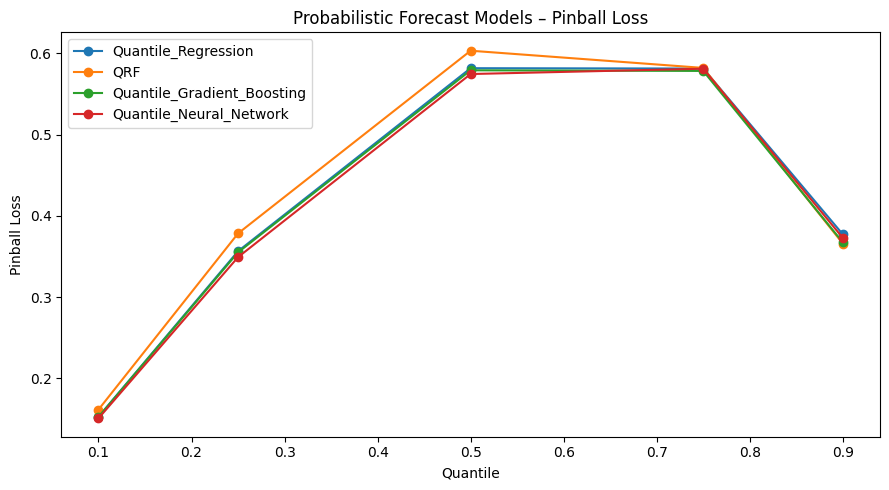

In [38]:
plt.figure(figsize=(9, 5))

for model_name in pinball_metrics["model"].unique():
    subset = pinball_metrics[pinball_metrics["model"] == model_name].sort_values("quantile")
    plt.plot(
        subset["quantile"],
        subset["pinball_loss"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Quantile")
plt.ylabel("Pinball Loss")
plt.title("Probabilistic Forecast Models – Pinball Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "probabilistic_pinball_loss_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Beispielgrafik: Quantile-Band

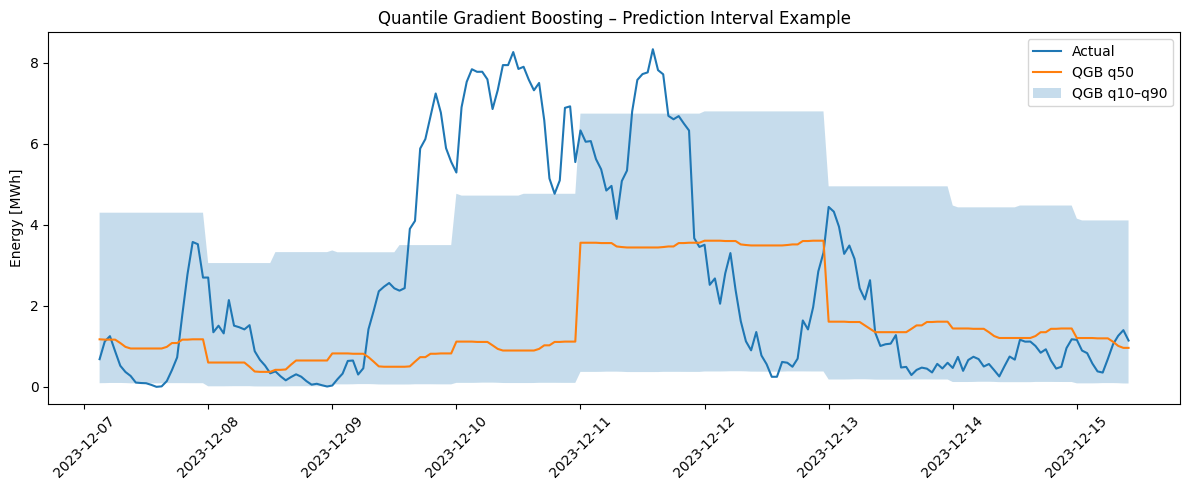

In [39]:
plot_window = min(200, len(y_test))

plot_data = pd.DataFrame({
    "timestamp": test_timestamps.iloc[:plot_window],
    "actual": y_test.iloc[:plot_window].to_numpy(),
    "q10": qgb_preds["q10"].iloc[:plot_window].to_numpy(),
    "q50": qgb_preds["q50"].iloc[:plot_window].to_numpy(),
    "q90": qgb_preds["q90"].iloc[:plot_window].to_numpy(),
})

plt.figure(figsize=(12, 5))
plt.plot(plot_data["timestamp"], plot_data["actual"], label="Actual")
plt.plot(plot_data["timestamp"], plot_data["q50"], label="QGB q50")
plt.fill_between(
    plot_data["timestamp"],
    plot_data["q10"],
    plot_data["q90"],
    alpha=0.25,
    label="QGB q10–q90",
)

plt.xticks(rotation=45)
plt.ylabel("Energy [MWh]")
plt.title("Quantile Gradient Boosting – Prediction Interval Example")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "qgb_prediction_interval_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


# Teil C – Gemeinsame Forecast Outputs

## 14. Gemeinsames Predictions-DataFrame erstellen

In [40]:
predictions = pd.DataFrame({
    "timestamp": test_timestamps.values,
    "y_true": y_test.to_numpy(),

    "persistence_gate": y_pred_persistence_gate,
    "elastic_net": y_pred_elastic_net,
    "random_forest": y_pred_random_forest,
    "gradient_boosting": y_pred_gradient_boosting,

    "quantile_regression_q10": qr_preds["q10"].to_numpy(),
    "quantile_regression_q25": qr_preds["q25"].to_numpy(),
    "quantile_regression_q50": qr_preds["q50"].to_numpy(),
    "quantile_regression_q75": qr_preds["q75"].to_numpy(),
    "quantile_regression_q90": qr_preds["q90"].to_numpy(),

    "qrf_q10": qrf_preds["q10"].to_numpy(),
    "qrf_q25": qrf_preds["q25"].to_numpy(),
    "qrf_q50": qrf_preds["q50"].to_numpy(),
    "qrf_q75": qrf_preds["q75"].to_numpy(),
    "qrf_q90": qrf_preds["q90"].to_numpy(),

    "qgb_q10": qgb_preds["q10"].to_numpy(),
    "qgb_q25": qgb_preds["q25"].to_numpy(),
    "qgb_q50": qgb_preds["q50"].to_numpy(),
    "qgb_q75": qgb_preds["q75"].to_numpy(),
    "qgb_q90": qgb_preds["q90"].to_numpy(),

    "qnn_q10": qnn_preds["q10"].to_numpy(),
    "qnn_q25": qnn_preds["q25"].to_numpy(),
    "qnn_q50": qnn_preds["q50"].to_numpy(),
    "qnn_q75": qnn_preds["q75"].to_numpy(),
    "qnn_q90": qnn_preds["q90"].to_numpy(),
})

print(predictions.shape)
predictions.head()

(13816, 26)


,timestamp,y_true,persistence_gate,elastic_net,random_forest,gradient_boosting,quantile_regression_q10,quantile_regression_q25,quantile_regression_q50,quantile_regression_q75,...,qgb_q10,qgb_q25,qgb_q50,qgb_q75,qgb_q90,qnn_q10,qnn_q25,qnn_q50,qnn_q75,qnn_q90
0,2023-12-07 03:00:00,0.683483,1.440683,1.735109,1.712108,1.694821,0.078341,0.407412,1.294931,2.480991,...,0.090291,0.343357,1.173904,2.377029,4.299697,0.156311,0.591537,1.689958,3.327141,5.003766
1,2023-12-07 04:00:00,1.120767,1.440683,1.710009,1.790606,1.694821,0.079038,0.400532,1.246877,2.384050,...,0.092044,0.343357,1.165868,2.377029,4.299697,0.166100,0.612103,1.699433,3.307512,4.957318
2,2023-12-07 05:00:00,1.251583,1.440683,1.680779,1.825095,1.694821,0.079564,0.391714,1.191615,2.283215,...,0.096253,0.343357,1.165868,2.377029,4.299697,0.173217,0.626701,1.704931,3.294596,4.928760
3,2023-12-07 06:00:00,0.879967,1.440683,1.649411,1.894520,1.694821,0.079881,0.381560,1.132910,2.185356,...,0.096253,0.343357,1.165868,2.377029,4.299697,0.174265,0.625279,1.690415,3.271869,4.907371
4,2023-12-07 07:00:00,0.521533,1.440683,1.618043,1.960409,1.694821,0.079968,0.370762,1.074762,2.097144,...,0.096253,0.343357,1.082071,2.364868,4.299697,0.170216,0.610903,1.661577,3.245276,4.897727


## 15. Beispielgrafik: Actual vs. ausgewählte Forecasts

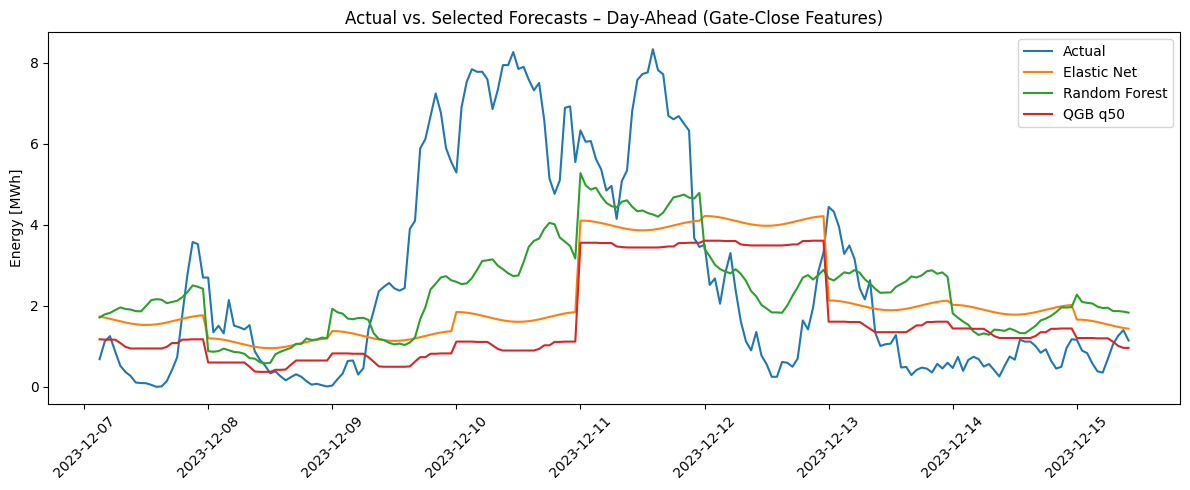

In [41]:
plot_window = min(200, len(predictions))

plt.figure(figsize=(12, 5))

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["y_true"].iloc[:plot_window],
    label="Actual",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["elastic_net"].iloc[:plot_window],
    label="Elastic Net",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["random_forest"].iloc[:plot_window],
    label="Random Forest",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["qgb_q50"].iloc[:plot_window],
    label="QGB q50",
)

plt.xticks(rotation=45)
plt.ylabel("Energy [MWh]")
plt.title("Actual vs. Selected Forecasts – Day-Ahead (Gate-Close Features)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "actual_vs_selected_forecasts_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()

## Hinweis zu xAI

Die erklärende Analyse der Modelle erfolgt nicht in diesem Forecasting-Notebook, sondern in Notebook 05.

Dort sollten insbesondere folgende Aspekte betrachtet werden:

- Koeffizienten von Elastic Net als interpretierbares Modell
- Feature Importances und SHAP für Random Forest, Gradient Boosting, QRF und Quantile Gradient Boosting
- Analyse von Zeitpunkten mit hohen Bidding-Verlusten aus Notebook 04

Notebook 03 erzeugt dafür nur die Forecasts, Modelle und Testfeatures.


## 16. Outputs speichern

In [42]:
predictions_path = FORECAST_DIR / "predictions_day_ahead.csv"
features_path = FORECAST_DIR / "test_features_day_ahead.csv"

point_metrics_path = TABLES_DIR / "point_forecast_metrics_day_ahead.csv"
prob_median_metrics_path = TABLES_DIR / "probabilistic_median_metrics_day_ahead.csv"
pinball_metrics_path = TABLES_DIR / "pinball_metrics_day_ahead.csv"

predictions.to_csv(predictions_path, index=False)
X_test.reset_index(drop=True).to_csv(features_path, index=False)

point_metrics.to_csv(point_metrics_path, index=False)
prob_median_metrics.to_csv(prob_median_metrics_path, index=False)
pinball_metrics.to_csv(pinball_metrics_path, index=False)

print("Saved:", predictions_path)
print("Saved:", features_path)
print("Saved:", point_metrics_path)
print("Saved:", prob_median_metrics_path)
print("Saved:", pinball_metrics_path)


Saved: C:\Users\felix\Documents\AI1\wind_bidding_project\results\forecasts\predictions_day_ahead.csv
Saved: C:\Users\felix\Documents\AI1\wind_bidding_project\results\forecasts\test_features_day_ahead.csv
Saved: C:\Users\felix\Documents\AI1\wind_bidding_project\results\tables\point_forecast_metrics_day_ahead.csv
Saved: C:\Users\felix\Documents\AI1\wind_bidding_project\results\tables\probabilistic_median_metrics_day_ahead.csv
Saved: C:\Users\felix\Documents\AI1\wind_bidding_project\results\tables\pinball_metrics_day_ahead.csv


## 17. Modelle speichern

In [43]:
joblib.dump(en_model, MODELS_DIR / "elastic_net_day_ahead.joblib")
joblib.dump(rf_model, MODELS_DIR / "random_forest_day_ahead.joblib")
joblib.dump(gb_model, MODELS_DIR / "gradient_boosting_day_ahead.joblib")

joblib.dump(qr_models, MODELS_DIR / "quantile_regression_day_ahead.joblib")
joblib.dump(qrf_model, MODELS_DIR / "qrf_day_ahead.joblib")
joblib.dump(qgb_models, MODELS_DIR / "quantile_gradient_boosting_day_ahead.joblib")
joblib.dump(qnn_model, MODELS_DIR / "quantile_neural_network_day_ahead.joblib")

print("Saved models to:", MODELS_DIR)


Saved models to: C:\Users\felix\Documents\AI1\wind_bidding_project\results\models


## 18. Zusammenfassung

In [ ]:
print("Point Forecast Metrics")
display(point_metrics)

print("Probabilistic Median Metrics")
display(prob_median_metrics)

print("Pinball Metrics")
display(pinball_metrics.sort_values(["quantile", "pinball_loss"]))


Point Forecast Metrics


,model,MAE,RMSE,R2
3,Gradient_Boosting,1.272480,1.682719,0.212914
1,Elastic_Net,1.263475,1.696554,0.199918
2,Random_Forest,1.280768,1.702543,0.194259
0,Persistence_gate,1.332470,2.042285,-0.159396


Probabilistic Median Metrics


,model,MAE,RMSE,R2
3,Quantile_Neural_Network_q50,1.148991,1.749662,0.149044
1,QRF_q50,1.206324,1.756649,0.142233
2,Quantile_Gradient_Boosting_q50,1.158168,1.766756,0.132334
0,Quantile_Regression_q50,1.163330,1.773976,0.125229


Pinball Metrics


,model,quantile,pinball_loss
15,Quantile_Neural_Network,0.10,0.150953
10,Quantile_Gradient_Boosting,0.10,0.152802
0,Quantile_Regression,0.10,0.152828
5,QRF,0.10,0.161711
16,Quantile_Neural_Network,0.25,0.349232
11,Quantile_Gradient_Boosting,0.25,0.355128
1,Quantile_Regression,0.25,0.356554
6,QRF,0.25,0.378409
17,Quantile_Neural_Network,0.50,0.574496
12,Quantile_Gradient_Boosting,0.50,0.579084


: 